<a href="https://colab.research.google.com/github/RayaRabbani129/PemMes_2026/blob/main/Minggu04/P03_Week04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pembuatan Dataset Sintetis**

In [2]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

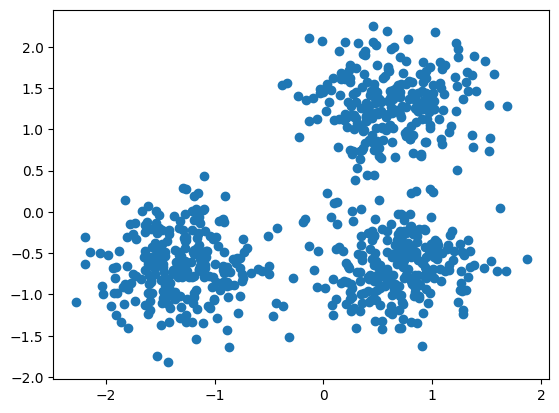

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

**Compute DBSCAN**

In [7]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


**Evaluasi Kualitas Klasterisasi**

In [10]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


**Visualisasi Hasil Klasterisasi**

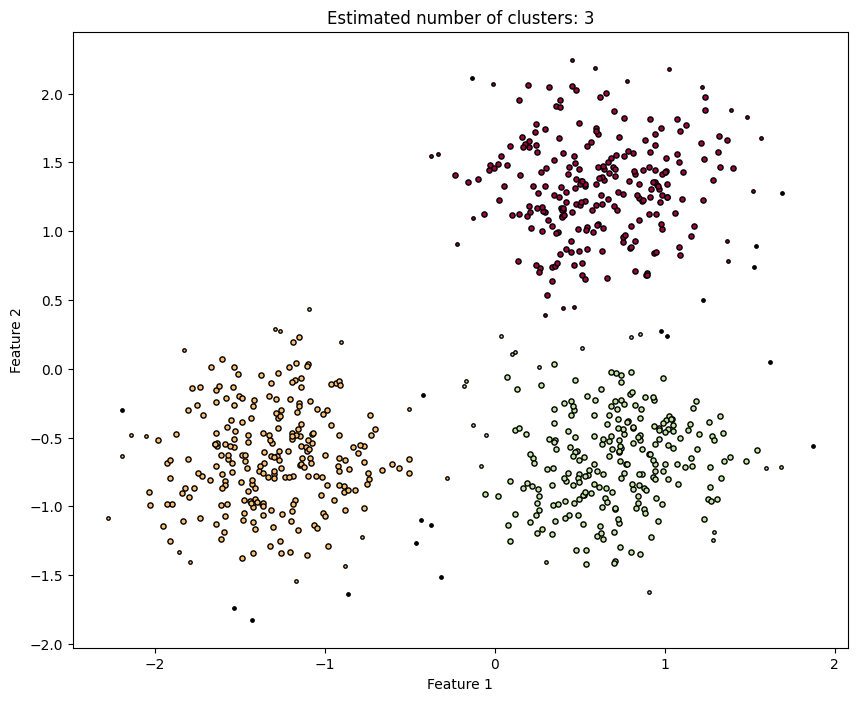

In [12]:
import numpy as np
import matplotlib.pyplot as plt

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Generate colors dynamically based on the number of unique labels
# Using np.linspace to get a good spread of colors from the colormap
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(10, 8)) # Create a figure for the plot

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise points.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    # Plot core samples
    plt.scatter(
        xy[:, 0],
        xy[:, 1],
        marker="o",
        facecolor=tuple(col),
        edgecolor="k",
        s=14, # 's' is the parameter for markersize in plt.scatter
    )

    xy = X[class_member_mask & ~core_samples_mask]
    # Plot non-core (border) samples
    plt.scatter(
        xy[:, 0],
        xy[:, 1],
        marker="o",
        facecolor=tuple(col),
        edgecolor="k",
        s=6, # 's' is the parameter for markersize in plt.scatter
    )

plt.title("Estimated number of clusters: %d" % n_clusters_) # Add a title to the plot
plt.xlabel("Feature 1") # Add x-axis label
plt.ylabel("Feature 2") # Add y-axis label
plt.show() # Display the plot